# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
| --- | --- |
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

### Ringkasan Informasi Dataset

| Metrik                  | Nilai                            |
|:------------------------|:---------------------------------|
| Jumlah Baris (Records)  | 6,819                            |
| Jumlah Kolom (Features) | 96                               |
| Total Missing Value     | 0                                |
| Status Missing Value    | Bersih (Tidak Ada Missing Value) |

### Distribusi Kelas Target (Bankrupt?)

| Kelas Kebangkrutan   |   Jumlah Perusahaan | Persentase   |
|:---------------------|--------------------:|:-------------|
| 0 (Tidak Bangkrut)   |                6599 | 96.77%       |
| 1 (Bangkrut)         |                 220 | 3.23%        |

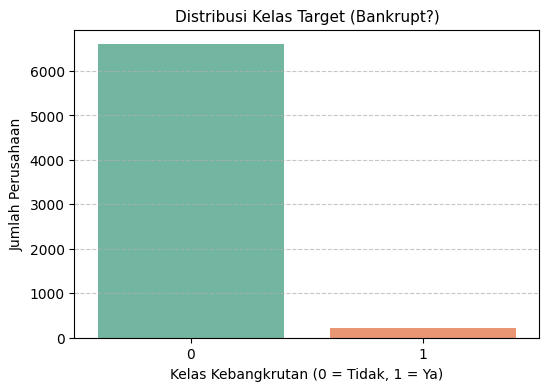

Catatan: Dataset tergolong imbalanced karena 96.77% data berada pada kelas 0 (Tidak Bangkrut).


### Sampel Statistik Deskriptif (5 Fitur Pertama)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
Realized Sales Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6138,1.0


### Distribusi Fitur Finansial per Kelas Target (Boxplot)

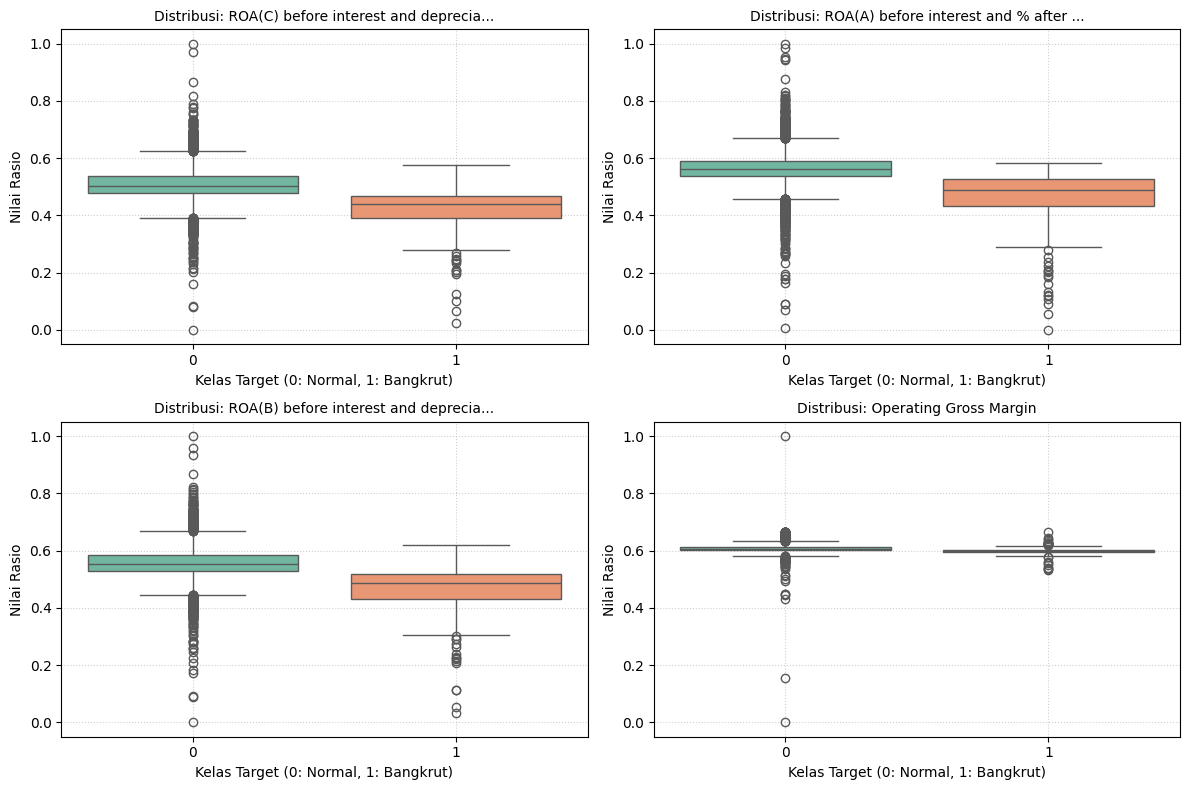

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

# Load dataset
df = pd.read_csv('bankruptcy.csv')

# Identifikasi kolom target
target_col = [col for col in df.columns if 'bankrupt' in col.lower()]
target_col = target_col[0] if len(target_col) > 0 else df.columns[0]

# --- 1. RINGKASAN DATASET ---
display(Markdown("### Ringkasan Informasi Dataset"))

info_ringkas = pd.DataFrame({
    'Metrik': ['Jumlah Baris (Records)', 'Jumlah Kolom (Features)', 'Total Missing Value', 'Status Missing Value'],
    'Nilai': [f"{df.shape[0]:,}", f"{df.shape[1]}", f"{df.isnull().sum().sum()}", 'Bersih (Tidak Ada Missing Value)']
})
# Sembunyikan indeks angka di samping kiri
display(Markdown(info_ringkas.to_markdown(index=False)))

# --- 2. CEK SEBARAN & ANALISIS IMBALANCED DATA ---
display(Markdown("### Distribusi Kelas Target (Bankrupt?)"))

counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

df_distribusi = pd.DataFrame({
    'Kelas Kebangkrutan': ['0 (Tidak Bangkrut)', '1 (Bangkrut)'],
    'Jumlah Perusahaan': [counts.get(0, 0), counts.get(1, 0)],
    'Persentase': [f"{percentages.get(0, 0):.2f}%", f"{percentages.get(1, 0):.2f}%"]
})
# Sembunyikan indeks angka di samping kiri
display(Markdown(df_distribusi.to_markdown(index=False)))

# Visualisasi Bar Plot Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
plt.title(f'Distribusi Kelas Target ({target_col})', fontsize=11)
plt.xlabel('Kelas Kebangkrutan (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Perusahaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Catatan: Dataset tergolong imbalanced karena {percentages.get(0, 0):.2f}% data berada pada kelas 0 (Tidak Bangkrut).")

# --- 3. DOKUMENTASI FITUR & STATISTIK DESKRIPTIF (SAMPEL 5 FITUR UTAMA) ---
display(Markdown("### Sampel Statistik Deskriptif (5 Fitur Pertama)"))
display(df.iloc[:, 1:6].describe().T.round(4))

# --- 4. VISUALISASI DISTRIBUSI FITUR DIBEDAKAN KELAS TARGET ---
display(Markdown("### Distribusi Fitur Finansial per Kelas Target (Boxplot)"))

feature_cols = [col for col in df.columns if col != target_col][:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette='Set2', ax=axes[i], legend=False)
    title_clean = col.strip()
    if len(title_clean) > 35:
        title_clean = title_clean[:35] + '...'
    axes[i].set_title(f'Distribusi: {title_clean}', fontsize=10)
    axes[i].set_xlabel('Kelas Target (0: Normal, 1: Bangkrut)')
    axes[i].set_ylabel('Nilai Rasio')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()